# 50 - Running Models on a GPU

**Section:** Running Models on GPUs | **Prereqs:** any FNN notebook | **Next:** `Weight Initialization/WeightMatrixSizeExplanation.ipynb`

The rule is one line long: **the model and the data must be on the same device.**
Mixing them raises `Expected all tensors to be on the same device`, which is the
most common runtime error in PyTorch.

```python
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)          # in place for Modules
x = x.to(device)          # NOT in place for tensors - reassign
```

**Two asymmetries worth memorising**
- `model.to(device)` moves the module in place; `tensor.to(device)` returns a
  *new* tensor and leaves the original alone. Forgetting to reassign is the usual
  cause of the device error.
- Anything leaving PyTorch - matplotlib, numpy, sklearn - needs `.cpu()` first,
  and `.detach()` if it still carries gradients.

**Use the `torch.device(...)` idiom, not a hardcoded `'cuda'`.** The same
notebook then runs on a machine without a GPU. Most notebooks in this course
hardcode `'cuda'`; this is the portable form.

**When the GPU is not faster:** small models and small batches are dominated by
the cost of moving data across the PCIe bus. GPUs win on large batches of large
tensors, which is also why batch size and GPU utilisation are linked.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time

### So we have to mode both the data and the model on the GPU to make it work.

In [ ]:
# The portable device idiom: use the GPU when there is one, fall back to CPU
# otherwise. Prefer this over a hardcoded .to('cuda').
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu') # better to use it rather than send the model directly to the cuda


print(device)

cuda


In [ ]:
# .to(device) on a Module moves every parameter IN PLACE. The return value is
# the same object, so `model.to(device)` alone is enough.
model = nn.Sequential(
    nn.Linear(10,10),
    nn.ReLU(),
    nn.Linear(10,1),
)

model.to(device)

Sequential(
  (0): Linear(in_features=10, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Creating a tensor directly on the device avoids an allocate-then-copy.
# For an existing tensor use x = x.to(device) - and note the reassignment:
# tensor.to() returns a NEW tensor rather than moving the old one.
data = torch.randn(10,10, device=device)

In [ ]:
# Both operands are on the same device, so this runs. Mixing devices raises
# 'Expected all tensors to be on the same device'.
output = model(data)

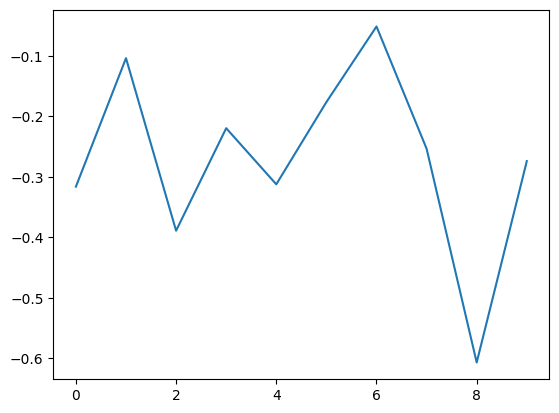

In [ ]:
# .cpu() before plotting: matplotlib cannot read CUDA memory.
# .detach() drops the autograd graph. The full idiom for getting a value out of
# PyTorch is .detach().cpu().numpy().
plt.plot(output.detach().cpu());